In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Preprocessing for Environmental Data

In [ ]:
import pandas as pd
import numpy as np

dataset_rainfall = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Average_Weather_data/avg_rainfall_dataset.csv')
dataset_solar = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Average_Weather_data/avg_solar_dataset.csv')
dataset_temp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Average_Weather_data/avg_max_temp_dataset.csv')

In [ ]:
dataset_rainfall.head()

,Variety,Reason,Year,Study,Location,ZS49PlHt,ZS49 (no days),HrvPlHt,ZS91 (no days),GrYld(kg/ha),...,03_rainfall,04_rainfall,05_rainfall,06_rainfall,07_rainfall,08_rainfall,09_rainfall,10_rainfall,11_rainfall,12_rainfall
0,Commander,AUS-CTL,2014,NtL,STHPER,55.0,92.0,72.0,131.0,NaN,...,0.23871,0.82,4.922581,3.12,4.877419,3.451613,2.566667,1.193548,0.793333,0.0
1,Commander,AUS-CTL,2014,18Hrs,STHPER,38.0,63.0,55.0,108.0,NaN,...,0.23871,0.82,4.922581,3.12,4.877419,3.451613,2.566667,1.193548,0.793333,0.0
2,Commander,AUS-CTL,2015,TOP1,NaN,NaN,104.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Commander,AUS-CTL,2015,TOP2,NaN,NaN,105.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Commander,AUS-CTL,2015,TOP3,NaN,NaN,96.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("RainfallL: ", dataset_rainfall.shape)
print("Solar: ", dataset_solar.shape)
print("Temperature: ", dataset_temp.shape)

RainfallL:  (6675, 22)
Solar:  (6675, 22)
Temperature:  (6675, 22)


In [ ]:
dataset_rainfall.drop(columns=['Variety', 'Reason','Location', 'ZS49PlHt', 'HrvPlHt', 'ZS91 (no days)', 'GrYld(kg/ha)'], inplace=True)
dataset_solar.drop(columns=['Variety', 'Reason','Location', 'ZS49PlHt', 'HrvPlHt', 'ZS91 (no days)', 'GrYld(kg/ha)'], inplace=True)
dataset_temp.drop(columns=['Variety', 'Reason','Location', 'ZS49PlHt', 'HrvPlHt', 'ZS91 (no days)', 'GrYld(kg/ha)'], inplace=True)

In [ ]:
dataset_rainfall['Study'] = dataset_rainfall['Study'].fillna('No Treatment')
dataset_solar['Study'] = dataset_solar['Study'].fillna('No Treatment')
dataset_temp['Study'] = dataset_temp['Study'].fillna('No Treatment')

In [ ]:
print("RainfallL: ", dataset_rainfall.shape)
print("Solar: ", dataset_solar.shape)
print("Temperature: ", dataset_temp.shape)

RainfallL:  (6675, 15)
Solar:  (6675, 15)
Temperature:  (6675, 15)


In [ ]:
dataset_temp.isnull().sum()

,0
Year,0
Study,0
ZS49 (no days),1458
01_temp_max,1335
02_temp_max,1335
03_temp_max,1335
04_temp_max,1335
05_temp_max,1335
06_temp_max,1335
07_temp_max,1335


In [ ]:
dataset_rainfall.dropna(inplace=True)
dataset_temp.dropna(inplace=True)
dataset_solar.dropna(inplace=True)

In [ ]:
print("RainfallL: ", dataset_rainfall.shape)
print("Solar: ", dataset_solar.shape)
print("Temperature: ", dataset_temp.shape)

RainfallL:  (4203, 15)
Solar:  (4203, 15)
Temperature:  (4203, 15)


In [ ]:
## selecting 5 timesteps to be using in LSTM
dataset_rainfall.drop(columns=['01_rainfall','02_rainfall','08_rainfall','09_rainfall','10_rainfall','11_rainfall','12_rainfall'], inplace=True)
dataset_solar.drop(columns=['01_solar','02_solar','08_solar','09_solar','10_solar','11_solar','12_solar'], inplace=True)
dataset_temp.drop(columns=['01_temp_max','02_temp_max','08_temp_max','09_temp_max','10_temp_max','11_temp_max','12_temp_max'], inplace=True)

# dataset_rainfall.drop(columns=['01_rainfall','02_rainfall','03_rainfall','04_rainfall','05_rainfall','06_rainfall','07_rainfall','12_rainfall'], inplace=True)
# dataset_solar.drop(columns=['01_solar','02_solar','03_solar','04_solar','05_solar','06_solar','07_solar','12_solar'], inplace=True)
# dataset_temp.drop(columns=['01_temp_max','02_temp_max','03_temp_max','04_temp_max','05_temp_max','06_temp_max','07_temp_max','12_temp_max'], inplace=True)

In [ ]:
dataset_rainfall.head()

,Year,Study,ZS49 (no days),03_rainfall,04_rainfall,05_rainfall,06_rainfall,07_rainfall
0,2014,NtL,92.0,0.238710,0.820000,4.922581,3.120000,4.877419
1,2014,18Hrs,63.0,0.238710,0.820000,4.922581,3.120000,4.877419
6,2016,18Hrs,85.0,0.541935,2.273333,3.612903,3.646667,4.503226
7,2015,No Treatment,77.0,2.812903,1.253333,0.529032,1.800000,1.754839
8,2016,No Treatment,87.9,0.419355,2.380000,0.980645,3.020000,4.154839


In [ ]:
dataset_rainfall.drop(columns=['Year'], inplace=True)
dataset_solar.drop(columns=['Year'], inplace=True)
dataset_temp.drop(columns=['Year'], inplace=True)

In [ ]:
target = dataset_rainfall['ZS49 (no days)'].values
target

array([ 92.,  63.,  85., ..., 121., 115., 120.])

In [ ]:
target.shape

(4203,)

In [ ]:
dataset_solar.head()

,Study,ZS49 (no days),03_solar,04_solar,05_solar,06_solar,07_solar
0,NtL,92.0,19.822581,15.283333,9.761290,9.740000,9.706452
1,18Hrs,63.0,19.822581,15.283333,9.761290,9.740000,9.706452
6,18Hrs,85.0,19.141935,13.290000,11.132258,10.080000,11.038710
7,No Treatment,77.0,18.977419,15.533333,14.080645,11.276667,11.222581
8,No Treatment,87.9,19.451613,15.583333,13.612903,11.680000,12.516129


In [ ]:
study = dataset_rainfall['Study'].values

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
study = labelencoder.fit_transform(study)
study

array([5, 0, 0, ..., 4, 1, 2])

In [ ]:
study.shape

(4203,)

In [ ]:
rainfall_data =dataset_rainfall.drop(columns=['Study', 'ZS49 (no days)'])
solar_data =dataset_solar.drop(columns=['Study', 'ZS49 (no days)'])
temp_data =dataset_temp.drop(columns=['Study', 'ZS49 (no days)'])

print(rainfall_data.shape)
print(solar_data.shape)
print(temp_data.shape)

(4203, 5)
(4203, 5)
(4203, 5)


In [ ]:
rainfall_data.head()

,03_rainfall,04_rainfall,05_rainfall,06_rainfall,07_rainfall
0,0.238710,0.820000,4.922581,3.120000,4.877419
1,0.238710,0.820000,4.922581,3.120000,4.877419
6,0.541935,2.273333,3.612903,3.646667,4.503226
7,2.812903,1.253333,0.529032,1.800000,1.754839
8,0.419355,2.380000,0.980645,3.020000,4.154839


In [ ]:
import numpy as np

rainfall_reshaped = rainfall_data.values.reshape(-1,5,1)
solar_reshaped = solar_data.values.reshape(-1,5,1)
temp_reshaped = temp_data.values.reshape(-1,5,1)

concatenated_data = np.concatenate((rainfall_reshaped, solar_reshaped, temp_reshaped), axis=2)

In [ ]:
rainfall_reshaped.shape

(4203, 5, 1)

In [ ]:
concatenated_data.shape

(4203, 5, 3)

### Data Preprocessing for gene

In [ ]:
merged_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/final_cleaned_merge_imputed.csv')
merged_df.drop(merged_df.columns[0], axis=1, inplace=True)
merged_df.head()

,Variety,Reason,Year,Study,Location,ZS49PlHt,ZS49 (no days),GrYld(kg/ha),D1H00051861,D1H000263584,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
0,Commander,1,0,5,4,55.0,92.0,NaN,1,1,...,1,1,1,1,1,1,0,1,1,1
1,Commander,1,0,0,4,38.0,63.0,NaN,1,1,...,1,1,1,1,1,1,0,1,1,1
2,Commander,1,2,3,4,NaN,NaN,NaN,1,1,...,1,1,1,1,1,1,0,1,1,1
3,Commander,1,2,0,4,70.0,85.0,NaN,1,1,...,1,1,1,1,1,1,0,1,1,1
4,Commander,1,1,4,1,56.9,77.0,2410.5,1,1,...,1,1,1,1,1,1,0,1,1,1


In [ ]:
dataset_zs49 = merged_df.copy()
dataset_yield = merged_df.copy()

dataset_zs49.drop(columns=['ZS49PlHt','GrYld(kg/ha)'], inplace=True)
dataset_zs49.head()

,Variety,Reason,Year,Study,Location,ZS49 (no days),D1H00051861,D1H000263584,D1H000275564,D1H000277624,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
0,Commander,1,0,5,4,92.0,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
1,Commander,1,0,0,4,63.0,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
2,Commander,1,2,3,4,NaN,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
3,Commander,1,2,0,4,85.0,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
4,Commander,1,1,4,1,77.0,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1


In [ ]:
dataset_zs49.dropna(subset=['ZS49 (no days)'], inplace=True)
dataset_zs49.shape

(4203, 30549)

In [ ]:
X = dataset_zs49.iloc[:, 6:]
y = dataset_zs49['ZS49 (no days)']

X.shape, y.shape

((4203, 30543), (4203,))

In [ ]:
X.head()

,D1H00051861,D1H000263584,D1H000275564,D1H000277624,D1H000277628,D1H000277656,D1H000277673,D1H000278185,D1H000278243,D1H000278386,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
0,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
1,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
3,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
4,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
5,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1


In [ ]:
dataset_yield.dropna(subset=['GrYld(kg/ha)'], inplace=True)
dataset_yield.iloc[:, 8:].head()

,D1H00051861,D1H000263584,D1H000275564,D1H000277624,D1H000277628,D1H000277656,D1H000277673,D1H000278185,D1H000278243,D1H000278386,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
4,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
5,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
6,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
7,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1
8,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,1,1,1


In [ ]:
X_yield = dataset_yield.iloc[:, 8:]
y_yield = dataset_yield['GrYld(kg/ha)']

X_yield.shape, y_yield.shape

((2617, 30543), (2617,))

### intermediate fusion - LSTM for Env and CNN for gene

In [ ]:
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input, concatenate, BatchNormalization, Conv1D, Activation, MaxPooling1D, Flatten, Embedding, Normalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

def intermediate_fusion(input_lstm, input_cnn, input_study):

    lstm_input = Input(shape = input_lstm, name = "LSTM_Input (Weather Data)")
    cnn_input = Input(shape = input_cnn, name = "CNN_Input (Gene Data)")
    study_input = Input(shape = input_study, name = "Study_Input (Treatment to Crop)")

    study_embedded = Embedding(input_dim=6, output_dim=3)(study_input)
    study_embedded = Flatten()(study_embedded)

    # Implement the intermediate fusion of the two inputs
    x_lstm = LSTM(223, return_sequences=True, name="LSTM_Layer_1")(lstm_input)
    x_lstm = Dropout(0.2)(x_lstm)
    x_lstm = LSTM(265, return_sequences = False, name="LSTM_Layer_2")(x_lstm)
    x_lstm = Dropout(0.2)(x_lstm)
    contact_study = concatenate([x_lstm,study_embedded], name="Concat_LSTM_Study")
    contact_study = BatchNormalization()(contact_study)
    x1 = Dense(136, activation='relu')(contact_study)
    x1 = Dropout(0.3)(x1)
    lstm_output = Dense(128, activation='relu', name="LSTM_Output")(x1)

    x = Conv1D(filters=64,kernel_size=5,padding='same',kernel_regularizer='L1L2', strides = 2, name="Conv1D_Layer_1")(cnn_input)
    x = Conv1D(filters=128,kernel_size=5,padding='same',kernel_regularizer='L1L2',strides = 1, name="Conv1D_Layer_2")(x)
    x = Conv1D(filters= 32,kernel_size=2,padding='same',kernel_regularizer='L1L2',strides = 1, name="Conv1D_Layer_3")(x)
    x = Conv1D(filters= 64,kernel_size=2,padding='same',kernel_regularizer='L1L2',strides = 1, name="Conv1D_Layer_4")(x)
    x= BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Flatten()(x)
    x = Dropout(0.87)(x)
    x= Activation('relu')(x)
    cnn_output = Dense(128)(x)

    concatenated = concatenate([lstm_output, cnn_output], name="Concat_LSTM_CNN")

    normalizer = Normalization()
    normalized_concat = normalizer(concatenated)

    z = Dense(128, activation='relu')(normalized_concat)
    z = Dropout(0.2)(z)
    final_output = Dense(1)(z)

    intermediate_fusion = Model(inputs=[lstm_input, cnn_input, study_input], outputs=final_output)

    optimizer = Adam(learning_rate=0.001)
    # optimizer = SGD(learning_rate=0.0009, momentum=0.77)

    intermediate_fusion.compile(optimizer=optimizer, loss='mean_squared_error', metrics=[tf.keras.metrics.RootMeanSquaredError()])

    return intermediate_fusion


In [ ]:
X_yield_cnn = X_yield.copy()
X_yield_cnn.shape

(2617, 30543)

In [ ]:
X_yield_cnn = X_yield_cnn.values.reshape(-1, X_yield_cnn.shape[1],1 )
X_yield_cnn.shape

(2617, 30543, 1)

In [ ]:
X_zs49_cnn = X.values.reshape(-1, X.shape[1],1 )
X_zs49_cnn.shape

(4203, 30543, 1)

In [ ]:
study.reshape(-1,1).shape

(4203, 1)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model
import os

kf = KFold(n_splits=3, shuffle=True, random_state=42)

final_train_mse, final_train_mae, final_train_r2 = [], [], []
final_test_mse,  final_test_mae, final_test_r2 = [], [],[]

# model_base_path = '/content/drive/MyDrive/Colab Notebooks/geno-pheno/best_model'


fold = 0

for train_index, test_index in kf.split(concatenated_data):
    X_train_lstm, X_test_lstm = concatenated_data[train_index], concatenated_data[test_index]
    X_train_cnn, X_test_cnn = X_zs49_cnn[train_index], X_zs49_cnn[test_index]
    X_study_train, X_study_test = study[train_index], study[test_index]
    y_train, y_test = target[train_index], target[test_index]

    fold += 1
    print(f"Fold #{fold}")
    print("--------------------------------")
    print(f"Train size LSTM: {X_train_lstm.shape}, Test size LSTM: {X_test_lstm.shape}")
    print("--------------------------------")
    print(f"Train size CNN: {X_train_cnn.shape}, Test size CNN: {X_test_cnn.shape}")
    print("--------------------------------")
    print(f"Train size Study: {X_study_train.shape}, Test size Study: {X_study_test.shape}")
    print("--------------------------------")

    # Scale data
    scaler = MinMaxScaler()
    X_train_scaled_lstm = scaler.fit_transform(X_train_lstm.reshape(-1, X_train_lstm.shape[-1])).reshape(X_train_lstm.shape)
    X_test_scaled_lstm = scaler.transform(X_test_lstm.reshape(-1, X_test_lstm.shape[-1])).reshape(X_test_lstm.shape)

    input_shape_lstm = (5, 3)  # (time_steps, features)
    input_shape_cnn = (X_train_cnn.shape[1], 1)  # (time_steps, features)
    input_shape_study = (1,)

    intermediate_fusion_model = intermediate_fusion(input_shape_lstm, input_shape_cnn, input_shape_study)
    # intermediate_fusion_model.summary()
    # plot_model(intermediate_fusion_model, to_file='/content/drive/MyDrive/Colab Notebooks/geno-pheno/model_summary.png', show_shapes=True, show_layer_names=True)
    # break

    # model_filepath = os.path.join(model_base_path, f"best_model_fold_{fold}.keras")
    # checkpoint = ModelCheckpoint(model_filepath, monitor='val_loss', save_best_only=True, verbose=1)

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = intermediate_fusion_model.fit(
        [X_train_scaled_lstm, X_train_cnn, X_study_train],
        y_train,
        batch_size=32,
        epochs=300,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    final_y_pred_test = intermediate_fusion_model.predict([X_test_scaled_lstm, X_test_cnn, X_study_test])
    final_y_pred_train = intermediate_fusion_model.predict([X_train_scaled_lstm, X_train_cnn, X_study_train])

    final_train_mse.append(mean_squared_error(y_train, final_y_pred_train))
    final_train_mae.append(mean_absolute_error(y_train, final_y_pred_train))
    final_train_r2.append(r2_score(y_train, final_y_pred_train))

    final_test_mse.append(mean_squared_error(y_test, final_y_pred_test))
    final_test_mae.append(mean_absolute_error(y_test, final_y_pred_test))
    final_test_r2.append(r2_score(y_test, final_y_pred_test))

    print(f'Train MSE: {np.mean(final_train_mse):.2f}')
    print(f'Test MSE: {np.mean(final_test_mse):.2f}')



Fold #1
--------------------------------
Train size LSTM: (2802, 5, 3), Test size LSTM: (1401, 5, 3)
--------------------------------
Train size CNN: (2802, 30543, 1), Test size CNN: (1401, 30543, 1)
--------------------------------
Train size Study: (2802,), Test size Study: (1401,)
--------------------------------
Epoch 1/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 187ms/step - loss: 42757.0430 - root_mean_squared_error: 188.4357 - val_loss: 1002.9884 - val_root_mean_squared_error: 31.6700
Epoch 2/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 180ms/step - loss: 591.6867 - root_mean_squared_error: 24.2840 - val_loss: 253.7249 - val_root_mean_squared_error: 15.9287
Epoch 3/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 174ms/step - loss: 419.1424 - root_mean_squared_error: 20.4427 - val_loss: 698.1863 - val_root_mean_squared_error: 26.4232
Epoch 4/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - loss: 472.9786 - root_mean_squared_error: 21.6232 - val_loss: 260.4859 - val_root_mean_squared_error: 16.1396
Epoch 5/300
71

In [ ]:
print(f'Train MSE: {np.mean(final_train_mse):.2f}')
print(f'Train RMSE: {np.sqrt(np.mean(final_train_mse)):.2f}')
print(f'Train MAE: {np.mean(final_train_mae):.2f}')
print(f'Train R2: {np.mean(final_train_r2):.2f}\n')
print(f'Standard deviation of Train MSE: {np.std(final_train_mse):.2f}\n')

print(f'Test MSE: {np.mean(final_test_mse):.2f}')
print(f'Test RMSE: {np.sqrt(np.mean(final_test_mse)):.2f}')
print(f'Test MAE: {np.mean(final_test_mae):.2f}')
print(f'Test R2: {np.mean(final_test_r2):.2f}')
print(f'Standard deviation of Test MSE: {np.std(final_test_mse):.2f}')

Train MSE: 75.78
Train RMSE: 8.71
Train MAE: 6.58
Train R2: 0.77

Standard deviation of Train MSE: 19.32

Test MSE: 88.47
Test RMSE: 9.41
Test MAE: 7.11
Test R2: 0.73
Standard deviation of Test MSE: 20.86


In [ ]:

# Train MSE: 88.01
# Train RMSE: 9.38
# Train MAE: 6.95
# Train R2: 0.73

# Standard deviation of Train MSE: 3.11

# Test MSE: 94.33
# Test RMSE: 9.71
# Test MAE: 7.21
# Test R2: 0.72
# Standard deviation of Test MSE: 5.39

#4 timestep - lr-0.0001
# Train MSE: 416746.17
# Train RMSE: 645.56
# Train MAE: 498.91
# Train R2: 0.66

# Standard deviation of Train MSE: 19043.62

# Test MSE: 633128.00
# Test RMSE: 795.69
# Test MAE: 623.61
# Test R2: 0.49
# Standard deviation of Test MSE: 33408.25


# 5 timestep
# Train MSE: 447580.96
# Train RMSE: 669.01
# Train MAE: 515.93
# Train R2: 0.64

# Standard deviation of Train MSE: 22325.67

# Test MSE: 634271.24
# Test RMSE: 796.41
# Test MAE: 623.82
# Test R2: 0.49
# Standard deviation of Test MSE: 52576.46

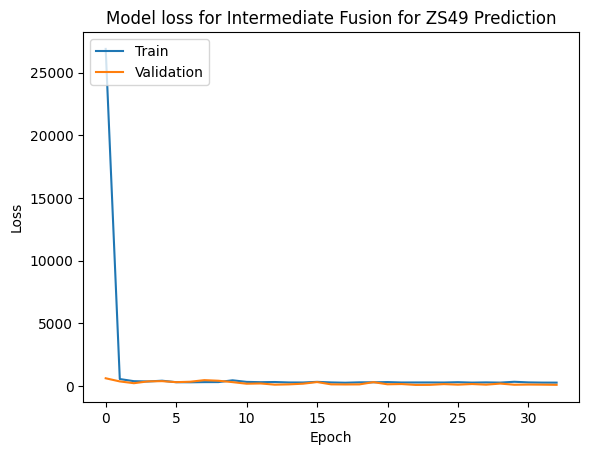

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss for Intermediate Fusion for ZS49 Prediction')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
# save the model
intermediate_fusion_model.save()